In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
path_fragmetns = "data/fasta/fragments.fasta"
path_sim_chromosome = "data/fasta/simulated_chromosome.fasta"

def read_fasta(file_path):
    if "fragments" in file_path:
        print(f"Reading fragments from {file_path}")
        with open(file_path, "r") as file:
            fragments_list = []
            current_fragment = []

            for line in file:
                line = line.strip()
                if not line:
                    continue
                if line.startswith(">"):
                    if current_fragment:
                        fragments_list.append("".join(current_fragment))
                        current_fragment = []
                else:
                    current_fragment.append(line)

            if current_fragment:
                fragments_list.append("".join(current_fragment))

        return fragments_list
    else:
        with open(file_path, 'r') as file:
            lines = file.readlines()
            sequence = ''.join(line.strip() for line in lines if not line.startswith('>'))
    return sequence

fragments = read_fasta(path_fragmetns)
sim_chromosome = read_fasta(path_sim_chromosome)

Reading fragments from data/fasta/fragments.fasta


In [4]:
# checking the lengths of the fragments and the simulated chromosome
print(len(fragments))
print(len(sim_chromosome))

18
5000


## Simulated Annealing

In [5]:

DENSE_THRESHOLD = 200

# Edge scoring defaults
MIN_OVERLAP = 20
PARTIAL_OVERLAP_FACTOR = 1.0  # use 1.0 or 2.0
USE_CANDIDATE_FILTER = True
KMER_SIZE = 8

# Neighbor cap for sparse mode
MAX_NEIGHBORS_PER_FRAGMENT = 50

In [ ]:
# =========================
# COST FUNCTION COMPONENTS
# =========================

def overlap_cost(seq1, seq2, min_overlap=10):
    """
    Calculates overlap cost between two adjacent fragments.
    
    Lower overlap → higher cost (disconnected reads)
    Returns negative of max overlap found (we want to maximize overlap)
    """
    len1, len2 = len(seq1), len(seq2)
    best_overlap = 0 # si incastrano perfettamente con 0
    
    # Try overlaps from min_overlap to min of the two lengths
    for overlap in range(min_overlap, min(len1, len2) + 1): # questo viene ripetuto da 10 a la sequenza più corta
        end_seq1 = seq1[-overlap:] # inizia dalla posizione overlap fino alla fine di seq1
        start_seq2 = seq2[:overlap]
        
        # Count matching bases
        matches = sum(1 for a, b in zip(end_seq1, start_seq2) if a == b)
        # zip da indietro a per seq1 e b per seq 2 in modo sequenziale, se a e b sono uguali é un match
        match_rate = matches / overlap
        
        # Good match if >80% similarity
        if match_rate > 0.8: 
            best_overlap = overlap
    
    # Cost: we want high overlap (penalize lack of overlap)
    cost = 100 if best_overlap < min_overlap else -best_overlap # figo scriverlo così
    return cost


def pair_penalty(permutation, pair_indices, max_distance=150, min_distance=-50):
    """
    Penalty for paired reads that are too far apart.
    
    pair_indices: dict mapping index → paired_index
    Returns penalty (0 if valid, large cost if violated)
    """
    penalty = 0
    
    # Find position of each read in the permutation
    pos = {read_idx: perm_pos for perm_pos, read_idx in enumerate(permutation)} # dictionary comprension
    # read idx --> ID Fragment
    
    for read_idx, paired_idx in pair_indices.items():
        if read_idx not in pos or paired_idx not in pos:
            continue
        
        # Distance in the permutation
        distance = pos[paired_idx] - pos[read_idx]
        
        # Check constraint: -50 <= distance <= 150
        if distance < min_distance or distance > max_distance:
            # Penalty proportional to how much we violate
            violation = max(abs(distance) - max_distance, min_distance - distance)
            penalty += max(0, violation) ** 2
    
    return penalty * 10  # Scale up the penalty


def cost_function(permutation, fragments, pair_indices=None):
    """
    Total cost of a permutation.
    
    f(π) = sum of adjacency costs + pair penalties
    """
    if pair_indices is None:
        pair_indices = {}
    
    total_cost = 0
    
    # Adjacency costs
    for i in range(len(permutation) - 1):
        frag_idx_1 = permutation[i]
        frag_idx_2 = permutation[i + 1]
        cost = overlap_cost(fragments[frag_idx_1], fragments[frag_idx_2])
        total_cost += cost
    
    # Pair penalties
    total_cost += pair_penalty(permutation, pair_indices)
    
    return total_cost

In [ ]:
# =========================
# NEIGHBORHOOD GENERATION
# =========================

def propose_neighbor(solution, rng, move_type=None):
    """
    Generate a neighboring permutation using one of three moves:
    - 'swap': exchange two reads
    - 'insert': remove and reinsert at different position
    - 'reverse': reverse a subsequence
    """
    neighbor = solution.copy()
    n = len(neighbor)
    
    if move_type is None:
        move_type = rng.choice(['swap', 'insert', 'reverse']) # ne sceglie uno casuale
    
    if move_type == 'swap':
        # Swap two random positions
        i, j = rng.choice(n, 2, replace=False)
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
    
    elif move_type == 'insert':
        # Remove element at random position and insert at another
        i = rng.integers(0, n)
        j = rng.integers(0, n)
        element = neighbor.pop(i)
        neighbor.insert(j, element)
    
    elif move_type == 'reverse':
        # Reverse a random subsequence
        i = rng.integers(0, n)
        j = rng.integers(i + 1, n + 1)
        neighbor[i:j] = neighbor[i:j][::-1]
    
    return neighbor


# =========================
# ACCEPTANCE LOGIC
# =========================

def acceptance_probability(delta, temperature):
    """
    Calculate acceptance probability for a move.
    P = exp(-Δ/T) where Δ = f(π') - f(π)
    """
    if delta < 0:  # Always accept improvements
        return 1.0
    return np.exp(-delta / temperature)


def cooling_schedule(T0, alpha, iteration):
    """
    Exponential cooling: T(t) = T0 * α^t
    """
    return T0 * (alpha ** iteration)

In [8]:
# =========================
# MAIN SIMULATED ANNEALING
# =========================

def simulated_annealing(
    fragments,
    T0=100.0,
    alpha=0.995,
    max_iterations=10000,
    pair_indices=None,
    seed=42,
    verbose=True
):
    """
    Simulated Annealing algorithm for fragment ordering.
    
    Parameters:
    -----------
    fragments : list of str
        DNA sequences to order
    T0 : float
        Initial temperature
    alpha : float
        Cooling rate (0 < alpha < 1)
    max_iterations : int
        Maximum number of iterations
    pair_indices : dict
        Mapping of paired reads (optional)
    seed : int
        Random seed for reproducibility
    verbose : bool
        Print progress
    
    Returns:
    --------
    dict with keys:
        - 'best_solution': best permutation found
        - 'best_cost': cost of best solution
        - 'cost_history': list of costs over iterations
        - 'temperature_history': list of temperatures
        - 'acceptance_rate_history': acceptance rates per iteration
    """
    rng = np.random.default_rng(seed)
    n_fragments = len(fragments)
    
    # Initialize with random permutation
    current_solution = list(rng.permutation(n_fragments))
    current_cost = cost_function(current_solution, fragments, pair_indices)
    
    best_solution = current_solution.copy()
    best_cost = current_cost
    
    # Tracking
    cost_history = [current_cost]
    temperature_history = [T0]
    acceptance_rate_history = []
    
    if pair_indices is None:
        pair_indices = {}
    
    # Main loop
    for iteration in range(max_iterations):
        temperature = cooling_schedule(T0, alpha, iteration)
        
        # Generate neighbor
        neighbor = propose_neighbor(current_solution, rng)
        neighbor_cost = cost_function(neighbor, fragments, pair_indices)
        
        # Accept/reject decision
        delta = neighbor_cost - current_cost
        
        if acceptance_probability(delta, temperature) > rng.random():
            # Accept neighbor
            current_solution = neighbor
            current_cost = neighbor_cost
            accepted = True
        else:
            accepted = False
        
        # Track best solution
        if current_cost < best_cost:
            best_solution = current_solution.copy()
            best_cost = current_cost
            if verbose and iteration % 1000 == 0:
                print(f"Iter {iteration}: new best cost = {best_cost:.1f}")
        
        # Record history
        cost_history.append(current_cost)
        temperature_history.append(temperature)
        acceptance_rate_history.append(1.0 if accepted else 0.0)
        
        # Early stopping if temperature too low
        if temperature < 1e-6:
            if verbose:
                print(f"Early stopping at iteration {iteration} (T < 1e-6)")
            break
    
    # Smooth acceptance rate for visualization
    acceptance_rate_smoothed = []
    window = min(100, max(1, max_iterations // 50))
    for i in range(len(acceptance_rate_history)):
        start = max(0, i - window // 2)
        end = min(len(acceptance_rate_history), i + window // 2)
        avg_rate = np.mean(acceptance_rate_history[start:end])
        acceptance_rate_smoothed.append(avg_rate)
    
    if verbose:
        print(f"\nSimulated Annealing completed!")
        print(f"Initial cost: {cost_history[0]:.1f}")
        print(f"Final best cost: {best_cost:.1f}")
        print(f"Improvement: {cost_history[0] - best_cost:.1f} ({100*(cost_history[0]-best_cost)/cost_history[0]:.1f}%)")
    
    return {
        'best_solution': best_solution,
        'best_cost': best_cost,
        'cost_history': cost_history,
        'temperature_history': temperature_history,
        'acceptance_rate_history': acceptance_rate_smoothed,
        'current_solution': current_solution,
        'current_cost': current_cost
    }

In [9]:
# =========================
# RUN SIMULATED ANNEALING
# =========================

# Simple example: no pair constraints for now
result = simulated_annealing(
    fragments=fragments,
    T0=100.0,
    alpha=0.995,
    max_iterations=5000,
    seed=42,
    verbose=True
)

Early stopping at iteration 3675 (T < 1e-6)

Simulated Annealing completed!
Initial cost: 1700.0
Final best cost: -856.0
Improvement: 2556.0 (150.4%)


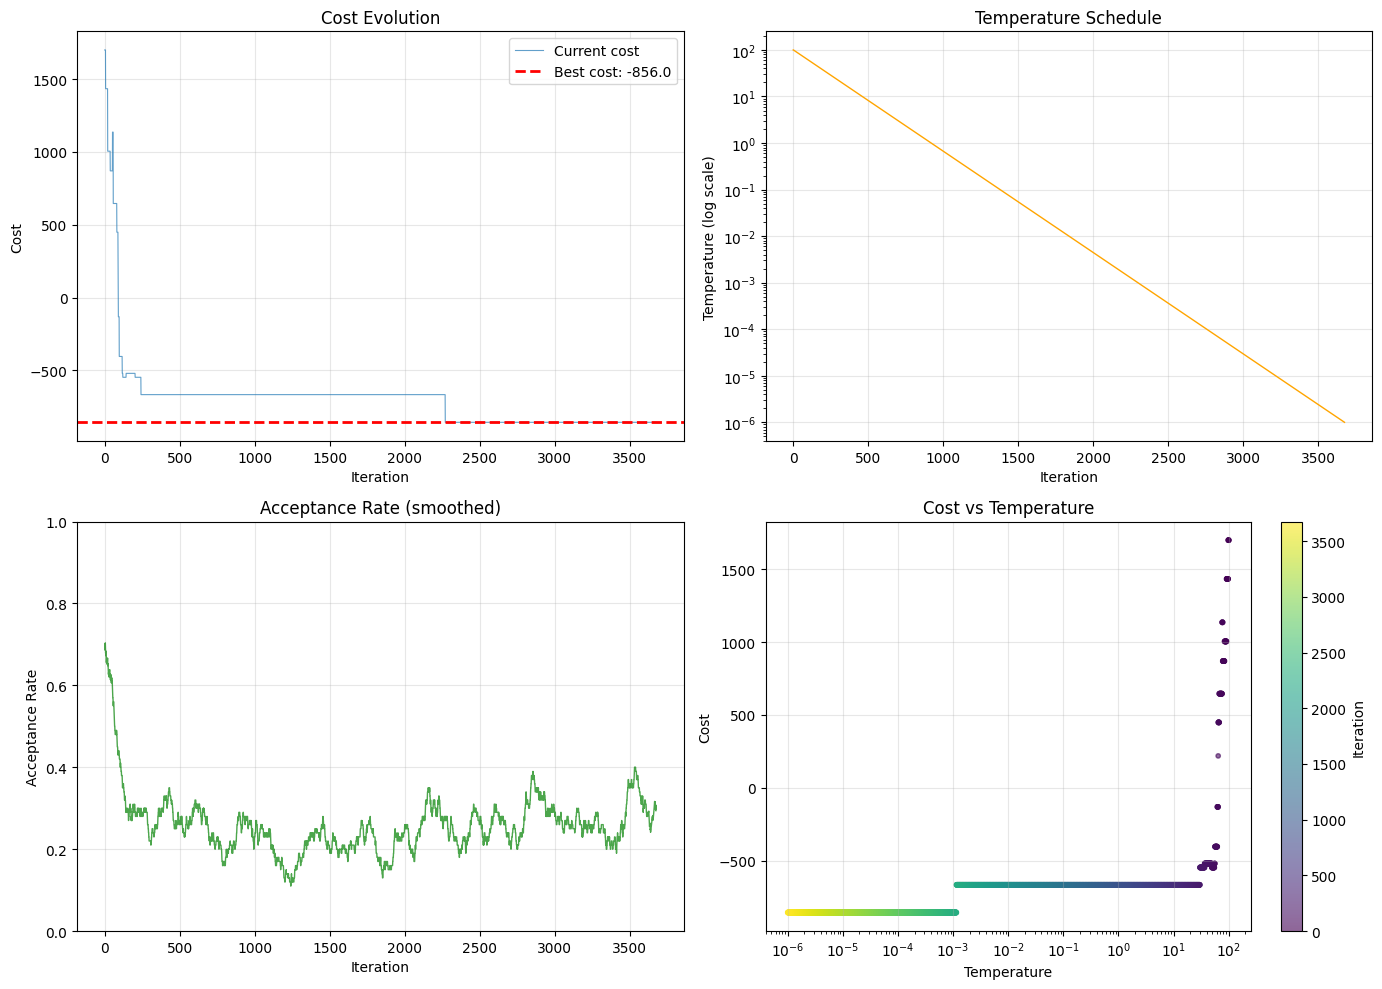

Cost reduction: 2556.0
Relative improvement: 150.4%


In [10]:
# =========================
# VISUALIZATIONS
# =========================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cost over iterations
ax = axes[0, 0]
ax.plot(result['cost_history'], linewidth=0.8, alpha=0.7, label='Current cost')
ax.axhline(result['best_cost'], color='r', linestyle='--', linewidth=2, label=f"Best cost: {result['best_cost']:.1f}")
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost')
ax.set_title('Cost Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Temperature decay
ax = axes[0, 1]
ax.semilogy(result['temperature_history'], linewidth=1, color='orange')
ax.set_xlabel('Iteration')
ax.set_ylabel('Temperature (log scale)')
ax.set_title('Temperature Schedule')
ax.grid(True, alpha=0.3)

# Plot 3: Acceptance rate
ax = axes[1, 0]
ax.plot(result['acceptance_rate_history'], linewidth=1, color='green', alpha=0.7)
ax.set_xlabel('Iteration')
ax.set_ylabel('Acceptance Rate')
ax.set_title('Acceptance Rate (smoothed)')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# Plot 4: Cost vs Temperature
ax = axes[1, 1]
scatter = ax.scatter(result['temperature_history'], result['cost_history'], 
                     c=range(len(result['cost_history'])), cmap='viridis', 
                     s=10, alpha=0.6)
ax.set_xlabel('Temperature')
ax.set_ylabel('Cost')
ax.set_title('Cost vs Temperature')
ax.set_xscale('log')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Iteration')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Cost reduction: {result['cost_history'][0] - result['best_cost']:.1f}")
print(f"Relative improvement: {100*(result['cost_history'][0] - result['best_cost'])/abs(result['cost_history'][0]):.1f}%")

In [11]:
# =========================
# SOLUTION ANALYSIS
# =========================

best_perm = result['best_solution']
print("=" * 70)
print("BEST SOLUTION FOUND")
print("=" * 70)
print(f"\nPermutation order (fragment indices):")
print(best_perm)
print(f"\nTotal cost: {result['best_cost']:.2f}")

# Analyze individual costs
print("\n" + "=" * 70)
print("COST BREAKDOWN")
print("=" * 70)

adjacency_cost = 0
for i in range(len(best_perm) - 1):
    frag_idx_1 = best_perm[i]
    frag_idx_2 = best_perm[i + 1]
    cost = overlap_cost(fragments[frag_idx_1], fragments[frag_idx_2])
    adjacency_cost += cost
    if i < 5 or i >= len(best_perm) - 3:  # Show first and last few
        print(f"  Fragment {frag_idx_1} → {frag_idx_2}: cost = {cost:.1f}")
    elif i == 5:
        print(f"  ... ({len(best_perm)-8} more pairs) ...")

print(f"\nTotal adjacency cost: {adjacency_cost:.2f}")
print(f"Pair penalty: {result['best_cost'] - adjacency_cost:.2f}")

# Algorithm statistics
print("\n" + "=" * 70)
print("ALGORITHM STATISTICS")
print("=" * 70)
print(f"Total iterations: {len(result['cost_history']) - 1}")
print(f"Initial cost: {result['cost_history'][0]:.2f}")
print(f"Final best cost: {result['best_cost']:.2f}")
print(f"Final current cost: {result['current_cost']:.2f}")
print(f"Improvement: {result['cost_history'][0] - result['best_cost']:.2f}")
improvement_pct = 100 * (result['cost_history'][0] - result['best_cost']) / abs(result['cost_history'][0])
print(f"Relative improvement: {improvement_pct:.2f}%")

# Acceptance statistics
acceptance_rates = result['acceptance_rate_history']
print(f"\nAverage acceptance rate (early): {np.mean(acceptance_rates[:len(acceptance_rates)//4]):.2%}")
print(f"Average acceptance rate (mid): {np.mean(acceptance_rates[len(acceptance_rates)//4:len(acceptance_rates)//2]):.2%}")
print(f"Average acceptance rate (late): {np.mean(acceptance_rates[3*len(acceptance_rates)//4:]):.2%}")
print(f"Overall average acceptance rate: {np.mean(acceptance_rates):.2%}")

BEST SOLUTION FOUND

Permutation order (fragment indices):
[np.int64(14), np.int64(0), np.int64(13), np.int64(9), np.int64(1), np.int64(5), np.int64(10), np.int64(15), np.int64(6), np.int64(16), np.int64(2), np.int64(7), np.int64(17), np.int64(8), np.int64(3), np.int64(12), np.int64(4), np.int64(11)]

Total cost: -856.00

COST BREAKDOWN
  Fragment 14 → 0: cost = 100.0
  Fragment 0 → 13: cost = -265.0
  Fragment 13 → 9: cost = -115.0
  Fragment 9 → 1: cost = -158.0
  Fragment 1 → 5: cost = -206.0
  ... (10 more pairs) ...
  Fragment 12 → 4: cost = 100.0
  Fragment 4 → 11: cost = 100.0

Total adjacency cost: -856.00
Pair penalty: 0.00

ALGORITHM STATISTICS
Total iterations: 3676
Initial cost: 1700.00
Final best cost: -856.00
Final current cost: -856.00
Improvement: 2556.00
Relative improvement: 150.35%

Average acceptance rate (early): 30.00%
Average acceptance rate (mid): 21.22%
Average acceptance rate (late): 28.26%
Overall average acceptance rate: 25.97%


In [12]:
# =========================
# PARAMETER SENSITIVITY ANALYSIS
# =========================

# Test different temperature and cooling rate combinations
temperatures = [50, 100, 200]
cooling_rates = [0.99, 0.995, 0.999]

results_grid = {}

print("Testing different parameter combinations...")
print("(This may take a minute)\n")

for T0 in temperatures:
    for alpha in cooling_rates:
        key = f"T0={T0}, α={alpha}"
        print(f"  {key}...", end=" ", flush=True)
        
        res = simulated_annealing(
            fragments=fragments,
            T0=T0,
            alpha=alpha,
            max_iterations=5000,
            seed=42,
            verbose=False
        )
        
        results_grid[key] = res['best_cost']
        print(f"best_cost={res['best_cost']:.1f}")

# Display results as table
print("\n" + "=" * 70)
print("PARAMETER SENSITIVITY RESULTS")
print("=" * 70)
print(f"{'T0 / α':<10}", end="")
for alpha in cooling_rates:
    print(f"{alpha:<15}", end="")
print()
print("-" * 60)

for T0 in temperatures:
    print(f"{T0:<10}", end="")
    for alpha in cooling_rates:
        key = f"T0={T0}, α={alpha}"
        cost = results_grid[key]
        print(f"{cost:<15.1f}", end="")
    print()


Testing different parameter combinations...
(This may take a minute)

  T0=50, α=0.99... best_cost=-856.0
  T0=50, α=0.995... best_cost=-856.0
  T0=50, α=0.999... best_cost=-856.0
  T0=100, α=0.99... best_cost=-856.0
  T0=100, α=0.995... best_cost=-856.0
  T0=100, α=0.999... best_cost=-856.0
  T0=200, α=0.99... best_cost=-641.0
  T0=200, α=0.995... best_cost=-641.0
  T0=200, α=0.999... best_cost=-641.0

PARAMETER SENSITIVITY RESULTS
T0 / α    0.99           0.995          0.999          
------------------------------------------------------------
50        -856.0         -856.0         -856.0         
100       -856.0         -856.0         -856.0         
200       -641.0         -641.0         -641.0         
